# テーマ4 分類の基礎

## 目的
- 分類が「入力データをカテゴリに割り当てる問題」であることを理解する
- Breast Cancer データセットで、良性・悪性を分類する流れを体験する
- Accuracy と混同行列を使って、正解率だけでは見えない誤分類の中身を確認する

## 今日の成果物
- 回帰と分類の違いを1文で説明する
- 分類モデルの Accuracy を確認する
- 混同行列から、どのクラスをどう間違えたかを説明する


## 分類の基本

分類は、入力データをあらかじめ決められたカテゴリに分ける問題です。回帰が数値を予測するのに対して、分類ではクラスを予測します。

例:

- メールがスパムかどうか
- 画像に写っている数字が何か
- 腫瘍データが良性か悪性か

この notebook では、医療判断を行うのではなく、分類モデルの評価方法を学ぶために Breast Cancer データセットを使います。


### このデータのラベルについて

`load_breast_cancer` では、`target=0` が malignant（悪性）、`target=1` が benign（良性）です。

医療判断をする教材ではありませんが、評価指標を読む練習としてはラベルの意味が重要です。この notebook では「悪性を見逃す」ことを重く考えるため、悪性を注目クラスとして Precision / Recall を確認します。


### Step 0: ライブラリを読み込む
分類で使うライブラリを準備します。ロジスティック回帰、k近傍法、決定木を同じ条件で比較します。


In [1]:
# ===== Step 0: ライブラリ読み込み =====
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# macOS 日本語フォント設定
fm._load_fontmanager(try_read_cache=False)
jp_font = FontProperties(family='Hiragino Sans')

sns.set_theme(style='whitegrid')

# seaborn の後にフォントを設定（seaborn が Arial を使うため）
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans']

Matplotlib is building the font cache; this may take a moment.


### Step 1: データを読み込む
Breast Cancer データセットを読み込み、分類の対象となるクラス名を確認します。この授業では診断ではなく、分類モデルの評価を学ぶ教材として扱います。


In [2]:
# ===== Step 1: データ読み込み =====
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()
target_column = 'target'

print('クラス名 =', list(cancer.target_names))
print('行数, 列数 =', df.shape)
display(df.head())


クラス名 = [np.str_('malignant'), np.str_('benign')]
行数, 列数 = (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 1-2: クラス分布を確認する
良性と悪性の件数比を可視化します。分類ではクラスの偏りがモデルに影響することがあります。

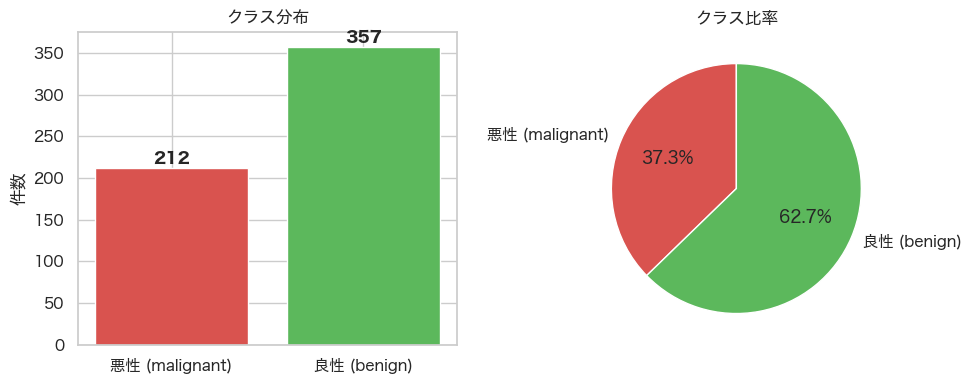

In [3]:
# ===== Step 1-2: クラス分布の可視化 =====
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 棒グラフでクラス分布
class_counts = df[target_column].value_counts().sort_index()
class_labels = ['悪性 (malignant)', '良性 (benign)']
axes[0].bar(class_labels, class_counts.values, color=['#D9534F', '#5CB85C'])
axes[0].set_title('クラス分布')
axes[0].set_ylabel('件数')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# パイチャートで比率
axes[1].pie(class_counts.values, labels=class_labels, autopct='%1.1f%%',
           colors=['#D9534F', '#5CB85C'], startangle=90)
axes[1].set_title('クラス比率')

plt.tight_layout()
plt.show()


### Step 2: 学習データを準備する
説明変数と目的変数を分けて、学習用とテスト用に分割します。分類ではクラスの偏りを保つため、`stratify` も確認します。


#### 解説: 標準化

kNN やロジスティック回帰では、特徴量のスケールが結果に影響することがあります。そこで、平均を0、標準偏差を1にそろえる標準化を行います。

特徴量 $x$ を標準化した値 $z$ は、次の式で表されます。

$$
z = \frac{x - \mu}{\sigma}
$$

ここで、$\mu$ は平均、$\sigma$ は標準偏差です。単位や値の大きさが違う特徴量を、比較しやすい形にそろえるための処理です。


In [4]:
# ===== Step 2: 学習データ準備 =====
feature_columns = cancer.feature_names[:10].tolist()  # TODO: 列数を変えて試してよい
X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train shape =', X_train.shape)
print('X_test shape =', X_test.shape)


X_train shape = (455, 10)
X_test shape = (114, 10)


### Step 2-2: 特徴量のクラス別分布
代表的な特徴量が良性・悪性でどのように異なるかを確認します。分類モデルは、こうした違いを利用して判断しています。

/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_23921/1709021333.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y='値', data=subset, ax=axes[i],
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_23921/1709021333.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y='値', data=subset, ax=axes[i],
/var/folders/0f/p1myltc16bq5dgqxpx4nq7j00000gp/T/ipykernel_23921/1709021333.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_column, y='値', data=subset, ax=axes[i],
/var/folders/

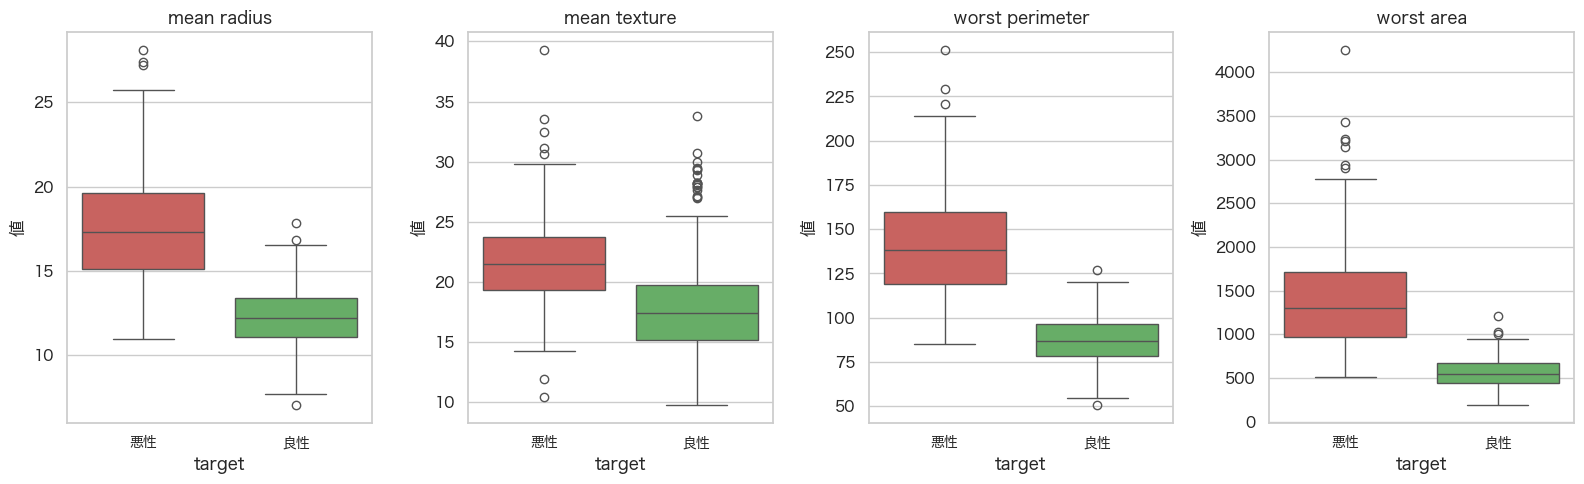

In [5]:
# ===== Step 2-2: 特徴量のクラス別ボックスプロット =====
# 代表的な特徴量を4つ選択して可視化
plot_features = ['mean radius', 'mean texture', 'worst perimeter', 'worst area']
df_plot = df[plot_features + [target_column]].copy()
df_plot[target_column] = df_plot[target_column].map({0: '悪性', 1: '良性'})

df_melted = df_plot.melt(id_vars=[target_column], value_name='値')

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, feat in enumerate(plot_features):
    subset = df_melted[df_melted['variable'] == feat]
    sns.boxplot(x=target_column, y='値', data=subset, ax=axes[i],
               palette={'悪性': '#D9534F', '良性': '#5CB85C'})
    axes[i].set_title(feat)
    axes[i].tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()


### Step 3: 分類モデルを学習する
ロジスティック回帰、kNN、決定木を学習させ、Accuracy を比べます。Accuracy は全体としてどれくらい当たったかを表します。


#### 解説: Accuracy と Precision / Recall

Accuracy は、全データのうち正しく分類できた割合です。

$$
Accuracy = \frac{正しく分類した件数}{全件数}
$$

ただし、Accuracy が高くても、重要なクラスを間違えている可能性があります。そこで、混同行列から Precision と Recall も確認します。

- Precision: 注目クラスと予測したもののうち、実際に注目クラスだった割合
- Recall: 実際に注目クラスだったもののうち、注目クラスと予測できた割合

Breast Cancer データでは、悪性を注目クラスとして扱います。悪性を良性と予測する見逃しを小さくしたいので、悪性クラスの Recall も重要です。


In [6]:
# ===== 追加演習: Accuracy を手計算のイメージで確認する =====
example_true = pd.Series([0, 1, 1, 0, 1])
example_pred = pd.Series([0, 1, 0, 0, 1])
manual_accuracy = (example_true == example_pred).mean()
print('正解したか:', (example_true == example_pred).tolist())
print('Accuracy:', manual_accuracy)


正解したか: [True, True, False, True, True]
Accuracy: 0.8


In [7]:
# ===== Step 3: 分類モデル =====
models = {
    'logistic_regression': LogisticRegression(max_iter=1000),
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'decision_tree': DecisionTreeClassifier(random_state=42, max_depth=4),
}

results = []
predictions_by_model = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    predictions_by_model[model_name] = preds
    results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, preds),
        'malignant_precision': precision_score(y_test, preds, pos_label=0),
        'malignant_recall': recall_score(y_test, preds, pos_label=0),
    })

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
display(results_df)


/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/k-z/.jupyter/li

,model,accuracy,malignant_precision,malignant_recall
2,decision_tree,0.929825,0.886364,0.928571
0,logistic_regression,0.894737,0.812500,0.928571
1,kNN,0.894737,0.826087,0.904762


### Step 3-2: モデル比較を可視化する
各モデルの Accuracy をグラフで比較します。表だけでなく、視覚的に違いを確認すると理解が深まります。

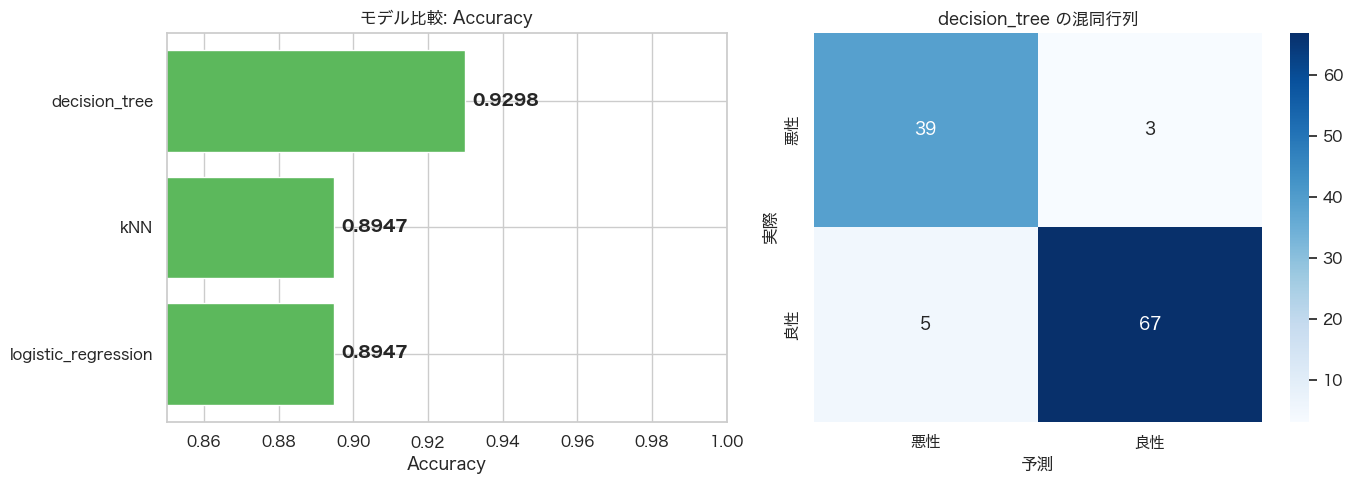

In [8]:
# ===== Step 3-2: モデル比較バーチャート =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_sorted = results_df.sort_values('accuracy')
axes[0].barh(results_sorted['model'], results_sorted['accuracy'], color='#5CB85C')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('モデル比較: Accuracy')
axes[0].set_xlim(0.85, 1.0)
for i, v in enumerate(results_sorted['accuracy']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

best_model_name = results_df.iloc[0]['model']
cm_best = confusion_matrix(y_test, predictions_by_model[best_model_name], labels=[0, 1])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['悪性', '良性'], yticklabels=['悪性', '良性'])
axes[1].set_xlabel('予測')
axes[1].set_ylabel('実際')
axes[1].set_title(f'{best_model_name} の混同行列')

plt.tight_layout()
plt.show()


In [9]:
# ===== 追加演習: 特徴量数を変えて比較する =====
# TODO: feature_count を 5, 10, 20, 30 に変えて結果を見る
feature_count = 10
feature_columns_trial = cancer.feature_names[:feature_count].tolist()
X_trial = df[feature_columns_trial]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_trial, y, test_size=0.2, random_state=42, stratify=y
)
scaler_t = StandardScaler()
X_train_t = scaler_t.fit_transform(X_train_t)
X_test_t = scaler_t.transform(X_test_t)

trial_model = LogisticRegression(max_iter=1000)
trial_model.fit(X_train_t, y_train_t)
trial_preds = trial_model.predict(X_test_t)
print('特徴量数:', feature_count)
print('Accuracy:', accuracy_score(y_test_t, trial_preds))


特徴量数: 10
Accuracy: 0.8947368421052632


/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/k-z/.jupyter/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/k-z/.jupyter/li

### Step 4: 混同行列を確認する
予測の間違い方を混同行列で見ます。どのクラスを取り違えやすいか、その間違いにどのような意味があるかを考えてください。


#### 解説: 混同行列から Precision と Recall を読む

2クラス分類の混同行列では、予測と実際の組み合わせを数えます。

| | 予測: 陰性 | 予測: 陽性 |
| --- | ---: | ---: |
| 実際: 陰性 | TN | FP |
| 実際: 陽性 | FN | TP |

- TP: 陽性を陽性と予測
- TN: 陰性を陰性と予測
- FP: 陰性を陽性と予測
- FN: 陽性を陰性と予測

ここから次の指標が計算できます。

- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)

どの間違いが問題になりやすいかは、データの文脈によって変わります。Breast Cancer では、悪性を見逃す FN が特に重要なので、Recall も見ます。

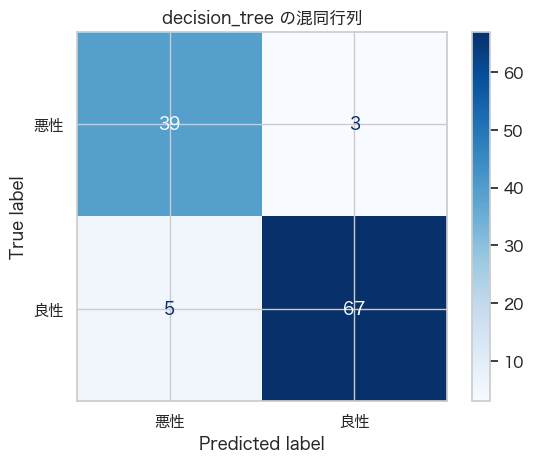

In [10]:
# ===== Step 4: 混同行列 =====
# TODO: model_name を変えて混同行列を比較する
model_name = results_df.iloc[0]['model']
cm = confusion_matrix(y_test, predictions_by_model[model_name])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['悪性', '良性'])
disp.plot(cmap='Blues')
plt.title(f'{model_name} の混同行列')
plt.show()


### Step 4-1: Precision と Recall を確認する
Accuracy だけでは見えない誤分類の偏りを、Precision と Recall で確認します。ここでは悪性を注目クラスとして、見逃しやすさも見てください。


In [11]:
model_name = results_df.iloc[0]['model']
preds = predictions_by_model[model_name]

print('model =', model_name)
print('accuracy =', accuracy_score(y_test, preds))
print('malignant precision =', precision_score(y_test, preds, pos_label=0))
print('malignant recall =', recall_score(y_test, preds, pos_label=0))


model = decision_tree
accuracy = 0.9298245614035088
malignant precision = 0.8863636363636364
malignant recall = 0.9285714285714286


## 振り返り
- 回帰と分類の違いを、自分の言葉で説明してください。
- どのモデルの Accuracy が高かったですか。
- 混同行列では、どのクラスをどのクラスとして間違えた例がありましたか。
- Accuracy だけで判断しない方がよい理由を説明してください。


## 演習課題

以下の演習をノートブック上で実行し、結果を確認してください。

### 演習1: 分類モデルの構築 (簡単)

1. Breast Cancerデータセットを読み込み、ロジスティック回帰で分類を行ってください。
2. テストデータでの正解率（Accuracy）を計算してください。
3. 混同行列を作成し、どのクラスを間違えやすいかを確認してください。

```python
# ここにコードを書いてください
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

X = df[cancer.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
malignant_recall = recall_score(y_test, preds, pos_label=0)
print(f"Accuracy: {acc:.3f}")
print(f"悪性クラスのRecall: {malignant_recall:.3f}")

cm = confusion_matrix(y_test, preds, labels=[0, 1])
print(f"Confusion Matrix（行=実際, 列=予測, 0=悪性, 1=良性）:\n{cm}")
```

### 演習2: 複数モデルの比較 (簡単)

1. ロジスティック回帰、k近傍法（KNN）、決定木の3つのモデルを比較してください。
2. 各モデルのAccuracyと混同行列を確認し、最も良い結果を出したモデルはどれですか。

```python
# ここにコードを書いてください
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: Accuracy = {acc:.3f}")
```

---

## レポート課題

以下のレポートを提出してください（A4 1ページ程度、またはノートブックのセルに記述）。

### レポート項目

1. **分類とは** (200字程度)
   - 分類問題が回帰問題とどのように違うか、自分の言葉で説明してください。また、分類が使われる現実世界の例を1つ挙げてください。

2. **混同行列の読み方** (200字程度)
   - 混同行列から何が読み取れますか。Accuracyだけではわからないことは何ですか。

3. **モデル比較の結果** (300字程度)
   - 演習で比較した3つのモデルについて、Accuracyと混同行列の結果をまとめてください。どのモデルが最も良く、なぜそう考えられるかを説明してください。

4. **誤分類の意味** (200字程度)
   - このデータセットでは、「良性を悪性と間違える（偽陽性）」と「悪性を良性と間違える（偽陰性）」のどちらの方が深刻ですか。理由を考えてください。

